In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:/Users/Lenovo V330/Downloads/Data Set For Task-20260407T142928Z-3-001/Data Set For Task/2) Stock Prices Data Set.csv")

In [3]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,02/01/2014,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,02/01/2014,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,02/01/2014,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,02/01/2014,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,02/01/2014,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [7]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [10]:
duplicates = df.duplicated().sum()

In [11]:
df.drop_duplicates(inplace=True)

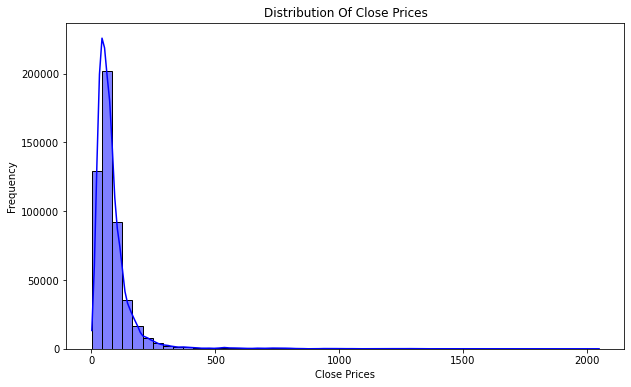

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['close'], bins=50, kde=True, color='blue')
plt.title('Distribution Of Close Prices')
plt.xlabel('Close Prices')
plt.ylabel('Frequency')

plt.show()

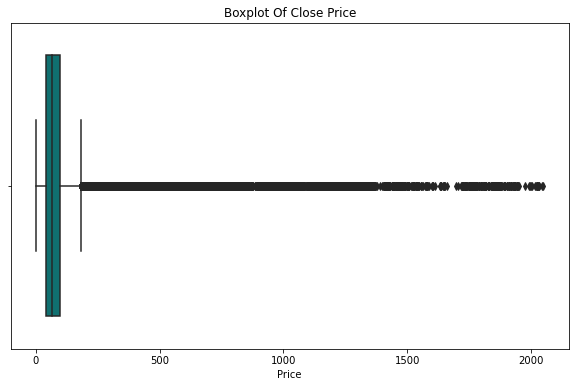

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['close'], color='teal')
plt.title('Boxplot Of Close Price')
plt.xlabel('Price')

plt.show()

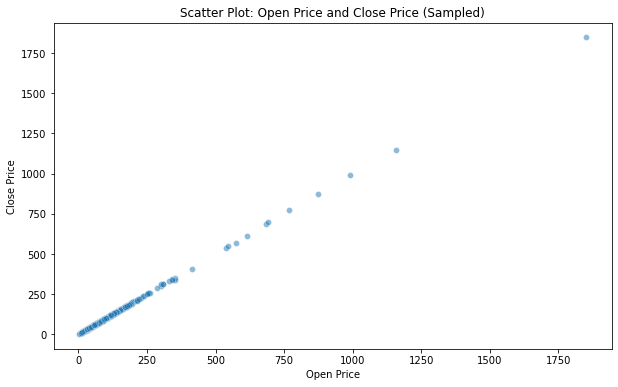

In [14]:
sample_df = df.sample(n=1000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='open', y='close', alpha=0.5)
plt.title('Scatter Plot: Open Price and Close Price (Sampled)')
plt.xlabel('Open Price')
plt.ylabel('Close Price')

plt.show()

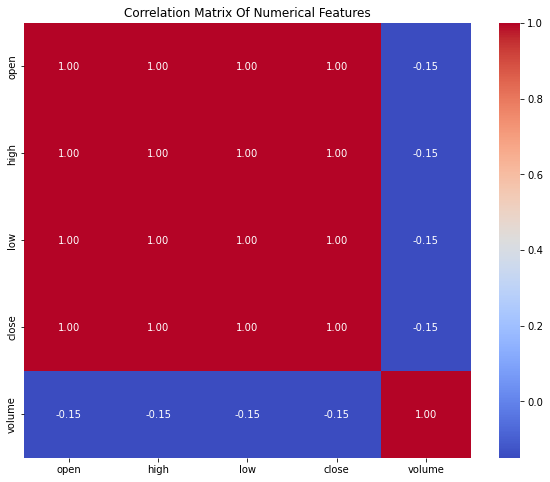

In [15]:
num_cols = df.select_dtypes(include=['number']).columns

correlation_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Of Numerical Features')

plt.show()

In [16]:
print(correlation_matrix)

            open      high       low     close    volume
open    1.000000  0.999941  0.999927  0.999856 -0.148724
high    0.999941  1.000000  0.999905  0.999918 -0.148344
low     0.999927  0.999905  1.000000  0.999922 -0.149284
close   0.999856  0.999918  0.999922  1.000000 -0.148839
volume -0.148724 -0.148344 -0.149284 -0.148839  1.000000


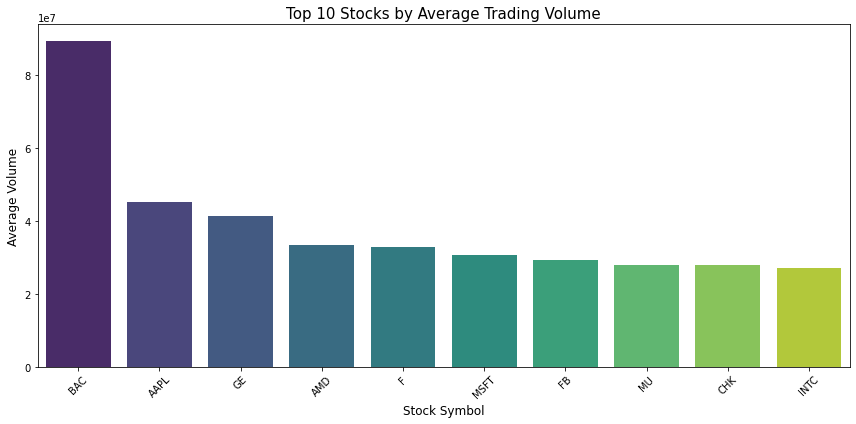

In [17]:
avg_volume = df.groupby('symbol')['volume'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_volume, x='symbol', y='volume', palette='viridis')
plt.title('Top 10 Stocks by Average Trading Volume', fontsize=15)
plt.xlabel('Stock Symbol', fontsize=12)
plt.ylabel('Average Volume', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
import warnings
warnings.filterwarnings("ignore")

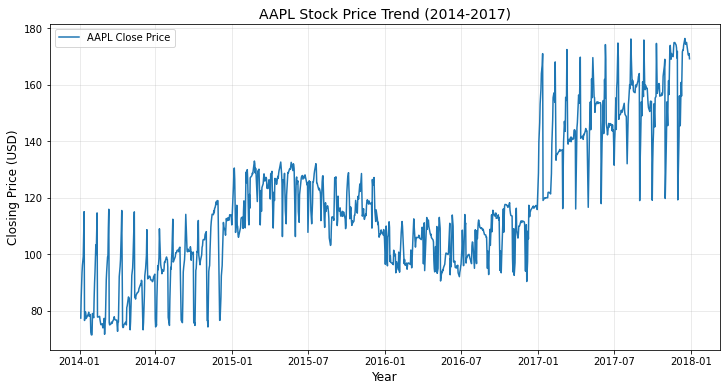

In [19]:
aapl_df = df[df['symbol'] == 'AAPL'].copy()
aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df = aapl_df.sort_values('date') 


plt.figure(figsize=(12, 6))
plt.plot(aapl_df['date'], aapl_df['close'], label='AAPL Close Price', color='tab:blue', linewidth=1.5)
plt.title('AAPL Stock Price Trend (2014-2017)', fontsize=14) 
plt.xlabel('Year', fontsize=12) 
plt.ylabel('Closing Price (USD)', fontsize=12) 
plt.legend(loc='upper left') 
plt.grid(True, alpha=0.3)

plt.show()

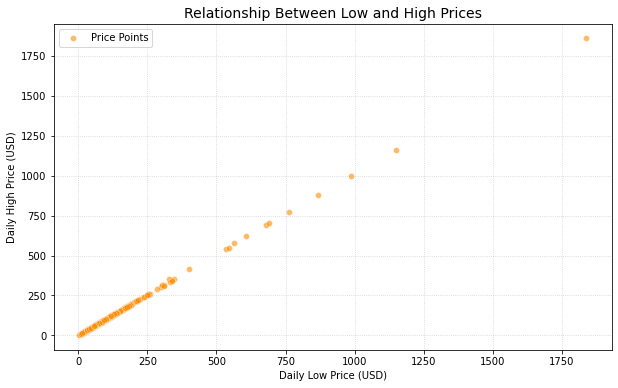

In [20]:
sample_df = df.sample(1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='low', y='high', alpha=0.6, color='darkorange', label='Price Points')
plt.title('Relationship Between Low and High Prices', fontsize=14)
plt.xlabel('Daily Low Price (USD)', fontsize=10)
plt.ylabel('Daily High Price (USD)', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [21]:
X = df[['open']]
y = df['close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
coeff = model.coef_[0]
intercept = model.intercept_


In [22]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Coefficient (Slope): {coeff:.4f}")
print(f"Intercept: {intercept:.4f}")

Mean Squared Error (MSE): 2.6477
R-squared: 0.9997
Coefficient (Slope): 1.0000
Intercept: 0.0213


In [23]:
plt.figure(figsize=(10, 6)) 
 
sample_X = X_test.sample(1000, random_state=1) 
sample_y = y_test.loc[sample_X.index] 
sample_pred = y_pred[X_test.index.get_indexer(sample_X.index)] 


<Figure size 720x432 with 0 Axes>

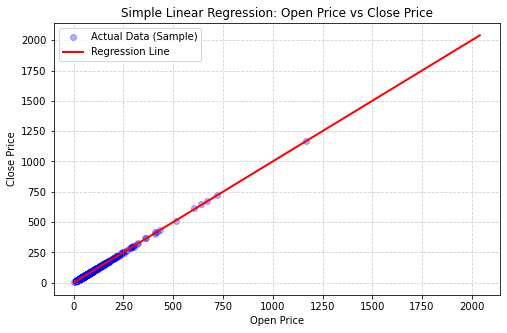

In [24]:
x_line = X_test.iloc[:, 0].values
y_line = y_pred

sorted_idx = x_line.argsort()

plt.figure(figsize=(8,5))
plt.scatter(sample_X, sample_y, color='blue', alpha=0.3, label='Actual Data (Sample)')
plt.plot(x_line[sorted_idx], y_line[sorted_idx], color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
aapl_df = df[df['symbol'] == 'AAPL'].copy() 

 
aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df = aapl_df.sort_values('date') 
aapl_df = aapl_df.dropna(subset=['close']) 
aapl_df.set_index('date', inplace=True) 


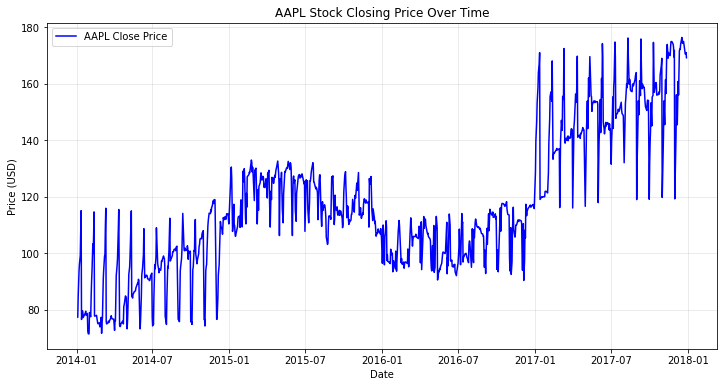

In [26]:
plt.figure(figsize=(12, 6)) 
plt.plot(aapl_df['close'], label='AAPL Close Price', color='blue') 
plt.title('AAPL Stock Closing Price Over Time')
plt.xlabel('Date') 
plt.ylabel('Price (USD)')
plt.legend() 
plt.grid(True, alpha=0.3)

plt.show()

In [27]:
aapl_df['MA50'] = aapl_df['close'].rolling(window=50).mean() 
aapl_df['MA200'] = aapl_df['close'].rolling(window=200).mean() 


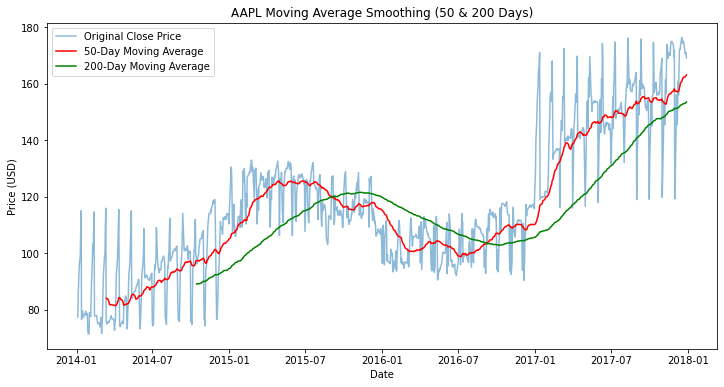

In [28]:
plt.figure(figsize=(12, 6)) 
plt.plot(aapl_df['close'], label='Original Close Price', alpha=0.5) 
plt.plot(aapl_df['MA50'], label='50-Day Moving Average', color='red', linewidth=1.5) 
plt.plot(aapl_df['MA200'], label='200-Day Moving Average', color='green', linewidth=1.5) 
plt.title('AAPL Moving Average Smoothing (50 & 200 Days)') 
plt.xlabel('Date') 
plt.ylabel('Price (USD)') 
plt.legend()

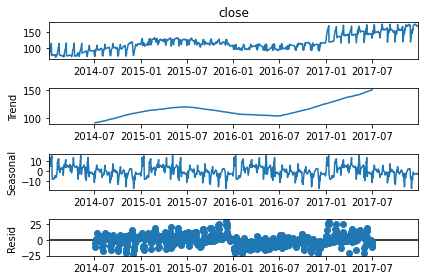

In [29]:
aapl_df = df[df['symbol'] == 'AAPL'].copy()

aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df = aapl_df.sort_values('date').dropna(subset=['close']).set_index('date')

result = seasonal_decompose(aapl_df['close'], model='additive', period=252)
result.plot()

plt.show()

In [30]:
stock_metrics = df.groupby('symbol').agg({
    'close': 'mean',
    'volume': 'mean'
}).dropna()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(stock_metrics)

wcss = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features) 
    wcss.append(kmeans.inertia_)

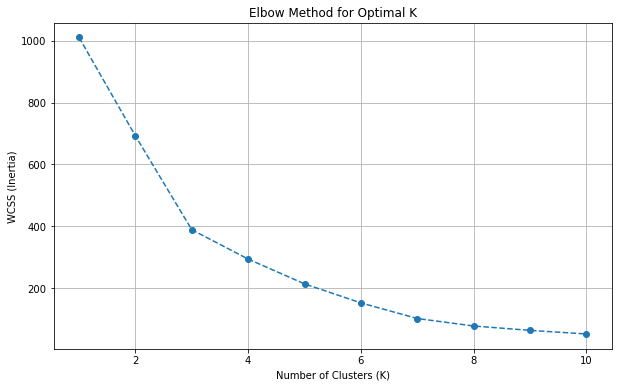

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--') 
plt.title('Elbow Method for Optimal K') 
plt.xlabel('Number of Clusters (K)') 
plt.ylabel('WCSS (Inertia)') 
plt.grid(True) 

plt.show()

In [32]:
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10) 
stock_metrics['cluster'] = kmeans.fit_transform(scaled_features).argmin(axis=1)
stock_metrics['cluster'] = kmeans.fit_predict(scaled_features)

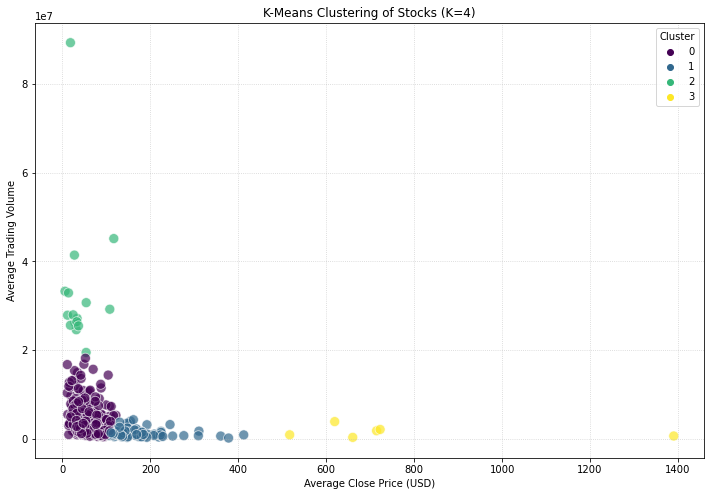

In [33]:
plt.figure(figsize=(12, 8)) 
sns.scatterplot(
    data=stock_metrics, 
    x='close', 
    y='volume', 
    hue='cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.7
) 
plt.title(f'K-Means Clustering of Stocks (K={optimal_k})') 
plt.xlabel('Average Close Price (USD)') 
plt.ylabel('Average Trading Volume') 
plt.legend(title='Cluster') 
plt.grid(True, linestyle=':', alpha=0.6)

In [34]:
data = df[df['symbol'] == 'AAPL'].sort_values('date').copy()
data['Target'] = (data['close'].shift(-1) > data['close']).astype(int)

data['Prev_Close'] = data['close'].shift(1)
data['Price_Diff'] = data['close'] - data['open']
data['MA5'] = data['close'].rolling(window=5).mean()
data['MA20'] = data['close'].rolling(window=20).mean()
data = data.dropna()

In [35]:
features = ['open', 'high', 'low', 'close', 'volume', 'Prev_Close', 'Price_Diff', 'MA5', 'MA20']

X = data[features]
y = data['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [37]:
 results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
}

results_df = pd.DataFrame(results).T
print("Initial Model Results:")

print(results_df)   

Initial Model Results:
               Accuracy        F1  Precision    Recall
Random Forest  0.848485  0.861111   0.815789  0.911765


In [38]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

In [39]:
best_params = grid_search.best_params_
report = classification_report(y_test, y_pred_best)

print("\nRandom Forest Tuning Summary")
print("Best Parameters:", best_params)
print(classification_report(y_test, y_pred_best))


Random Forest Tuning Summary
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.89      0.79      0.84        96
           1       0.82      0.91      0.87       102

    accuracy                           0.85       198
   macro avg       0.86      0.85      0.85       198
weighted avg       0.86      0.85      0.85       198



Text(51.0, 0.5, 'Actual')

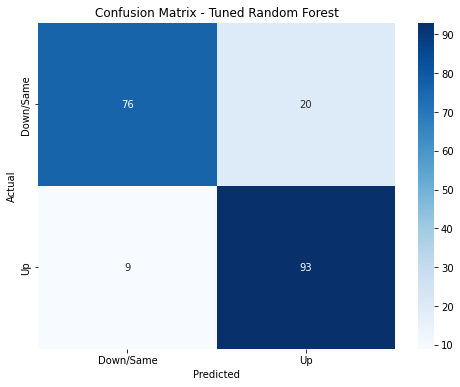

In [40]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down/Same', 'Up'], yticklabels=['Down/Same', 'Up'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [41]:
data = df[df['symbol'] == 'AAPL'].copy()
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')

data['Target'] = (data['close'].shift(-1) > data['close']).astype(int)

data['Return'] = data['close'].pct_change()
data['MA5'] = data['close'].rolling(window=5).mean()
data['MA20'] = data['close'].rolling(window=20).mean()
data['Vol_Change'] = data['volume'].pct_change()

data = data.dropna()

In [42]:
features = ['open', 'high', 'low', 'close', 'volume', 'Return', 'MA5', 'MA20', 'Vol_Change']
X = data[features]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
}


In [44]:
results_df = pd.DataFrame(results).T
print("Initial Model Results:")

print(results_df)

Initial Model Results:
                     Accuracy  Precision    Recall  F1-score
Logistic Regression  0.606061   0.610687  0.747664  0.672269
Decision Tree        0.525253   0.685714  0.224299  0.338028
Random Forest        0.550505   0.593750  0.532710  0.561576


In [45]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

In [46]:
best_params = grid_search.best_params_
report = classification_report(y_test, y_pred_best)

print("\nRandom Forest Tuning Summary")
print("Best Parameters:", best_params)
print(classification_report(y_test, y_pred_best))


Random Forest Tuning Summary
Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.51      0.53      0.52        91
           1       0.58      0.56      0.57       107

    accuracy                           0.55       198
   macro avg       0.54      0.54      0.54       198
weighted avg       0.55      0.55      0.55       198



Text(0.5, 1.0, 'Confusion Matrix - Random Forest')

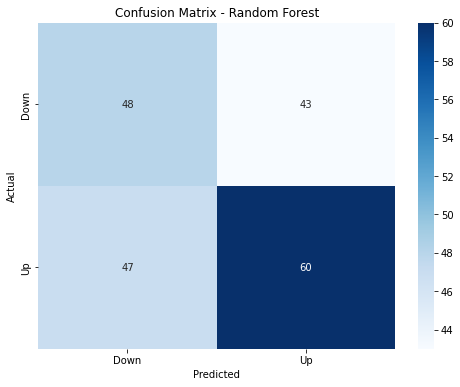

In [47]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')



In [48]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1": f1_score(y_test, y_pred_best)
}

In [49]:
features = ['open', 'high', 'low', 'close', 'volume', 'MA5', 'MA20', 'Target']

clean_data = data[features].dropna()

X = clean_data[['open', 'high', 'low', 'close', 'volume', 'MA5', 'MA20']]
y = clean_data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [50]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_search.fit(X_train_scaled, y_train)


y_pred = grid_search.predict(scaler.transform(X_test))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.51      0.51        91
           1       0.58      0.59      0.59       107

    accuracy                           0.55       198
   macro avg       0.55      0.55      0.55       198
weighted avg       0.55      0.55      0.55       198



In [51]:
df.to_csv('cleaned_stock_prices.csv', index=False)